# **Emotion Classification with Hugging Face Models and Sentence Embeddings**

**Nama:** Karinda Amelia  
**Email:** karindaamelia21@gmail.com

## **1. Imports & Setup**

In [1]:
# Standard libraries
import os
import random
import re
import warnings

# Data & numeric
import numpy as np
import pandas as pd

# Utilities & NLP support
import joblib
import torch

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Hugging Face datasets
from datasets import load_dataset

# Sentence-transformers
from sentence_transformers import SentenceTransformer

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [2]:
# Disable warnings
warnings.filterwarnings("ignore")

In [3]:
# display settings
pd.set_option("display.max_colwidth", 400)
sns.set(style="whitegrid")

In [4]:
# Reproducibility
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

## **2. Load Dataset**

In [5]:
# Load dataset with default splits: train, validation, test
dataset = load_dataset("dair-ai/emotion")   # Hugging Face provides train, validation, test splits

# Convert to Pandas DataFrame for tabular preview
train_df = pd.DataFrame(dataset["train"])
validation_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

In [6]:
# Preview first 5 rows of each split
print("Train split preview:")
display(train_df.head())

print("\nValidation split preview:")
display(validation_df.head())

print("\nTest split preview:")
display(test_df.head())

Train split preview:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3



Validation split preview:


,text,label
0,im feeling quite sad and sorry for myself but ill snap out of it soon,0
1,i feel like i am still looking at a blank canvas blank pieces of paper,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1



Test split preview:


,text,label
0,im feeling rather rotten so im not very ambitious right now,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,0
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,1
4,i was feeling a little vain when i did this one,0


In [7]:
# Display number of examples per split
for split_name, split_df in zip(["train", "validation", "test"], [train_df, validation_df, test_df]):
    print(f"{split_name} set: {len(split_df)} examples")

train set: 16000 examples
validation set: 2000 examples
test set: 2000 examples


## **3. Exploratory Data Analysis (EDA)**

In [8]:
# 1. Dataset overview
print("Dataset overview (train split):")
print(f"Number of rows: {train_df.shape[0]}")
print(f"Number of columns: {train_df.shape[1]}")

print("\nColumns, data types, and non-null counts:")
train_df.info()

# Preview first 5 rows
display(train_df.head())

Dataset overview (train split):
Number of rows: 16000
Number of columns: 2

Columns, data types, and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3



Class distribution (train split):


label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

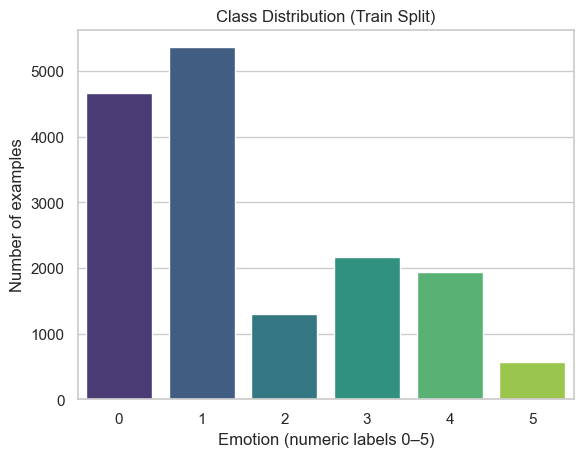

In [9]:
# 2. Class distribution (numeric labels)
label_counts = train_df['label'].value_counts().sort_index()
print("\nClass distribution (train split):")
display(label_counts)

# Visualize class distribution
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Class Distribution (Train Split)")
plt.xlabel("Emotion (numeric labels 0–5)")
plt.ylabel("Number of examples")
plt.show()

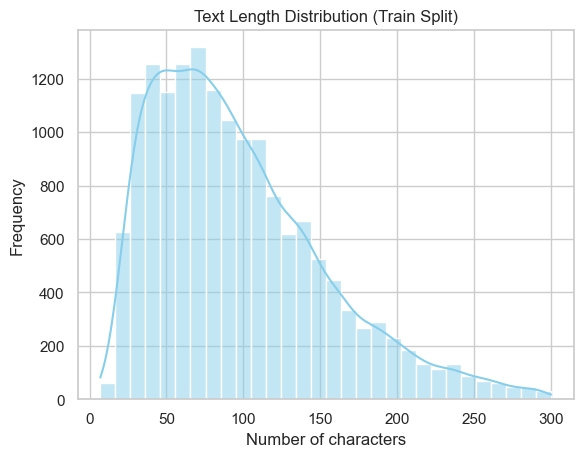


Text length statistics (train split):


count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
Name: text_length, dtype: float64

In [10]:
# 3. Text length analysis
train_df['text_length'] = train_df['text'].apply(len)

# Histogram of text length
sns.histplot(train_df['text_length'], bins=30, kde=True, color='skyblue')
plt.title("Text Length Distribution (Train Split)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

# Quick statistics of text length
print("\nText length statistics (train split):")
display(train_df['text_length'].describe())

## **4. Text Preprocessing**

In [11]:
# Text Preprocessing Function
def preprocess_text(text: str) -> str:
    """
    Clean and normalize input text for NLP tasks.

    Steps:
    1. Convert all text to lowercase.
    2. Remove URLs (http://, https://, www.).
    3. Remove punctuation and special characters.
    4. Normalize whitespace (remove extra spaces/newlines).

    Args:
        text (str): Raw input text.

    Returns:
        str: Cleaned and normalized text.
    """
    
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http[s]?://\S+|www\.\S+", "", text)
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [12]:
# Apply preprocessing to all dataset splits
for df in [train_df, validation_df, test_df]:
    df['clean_text'] = df['text'].apply(preprocess_text)

# Preview the cleaned text
display(train_df[['text','clean_text']].head())

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,i am ever feeling nostalgic about the fireplace i will know that it is still on the property
4,i am feeling grouchy,i am feeling grouchy


## **5. Labeling**

In [13]:
# Map Numeric Labels to Human-Readable Emotion Names

"""
The original dataset uses numeric labels (0-5) to represent emotions.
For better interpretability, we map these numeric labels to human-readable
emotion names and create a new column 'emotion' in each dataset split.
"""

# Define label mapping
label_names = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

# Apply the mapping to all dataset splits
for df in [train_df, validation_df, test_df]:
    df['emotion'] = df['label'].map(label_names)

# Preview the first few rows of the train split
print("Sample of train split after labeling:")
display(train_df[['text', 'clean_text', 'label', 'emotion']].head())


Sample of train split after labeling:


,text,clean_text,label,emotion
0,i didnt feel humiliated,i didnt feel humiliated,0,Sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0,Sadness
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,3,Anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2,Love
4,i am feeling grouchy,i am feeling grouchy,3,Anger


## **6. Label Exploration**

In [14]:
# Label order based on numeric labels
label_order = [0, 1, 2, 3, 4, 5]  # existing numeric labels

In [15]:
# Display number of examples per label
print("Number of examples per label (train split):\n")

# Create a summary DataFrame
summary_df = train_df.groupby(['label','emotion']).size().reset_index(name='count')
summary_df = summary_df.sort_values('label')  # ensure order by numeric label

display(summary_df)

Number of examples per label (train split):



,label,emotion,count
0,0,Sadness,4666
1,1,Joy,5362
2,2,Love,1304
3,3,Anger,2159
4,4,Fear,1937
5,5,Surprise,572


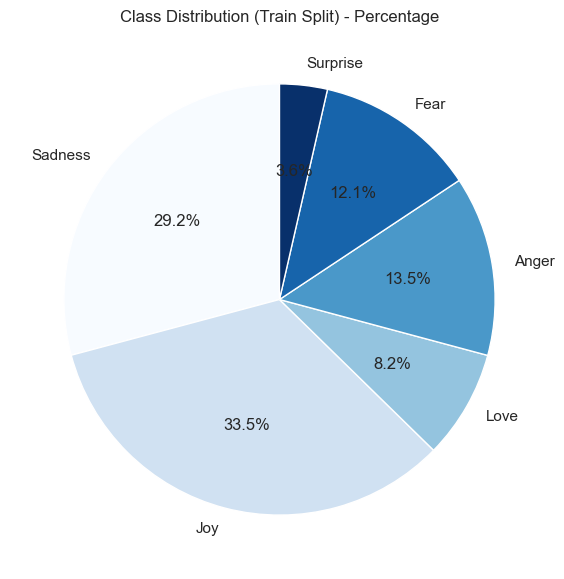

In [16]:
# Pie chart 
blues = cm.get_cmap('Blues', len(label_counts))
colors = blues(np.arange(len(label_counts)))

plt.figure(figsize=(7,7))
plt.pie(
    label_counts.values,
    labels=[label_names[i] for i in label_counts.index],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)
plt.title("Class Distribution (Train Split) - Percentage")
plt.show()


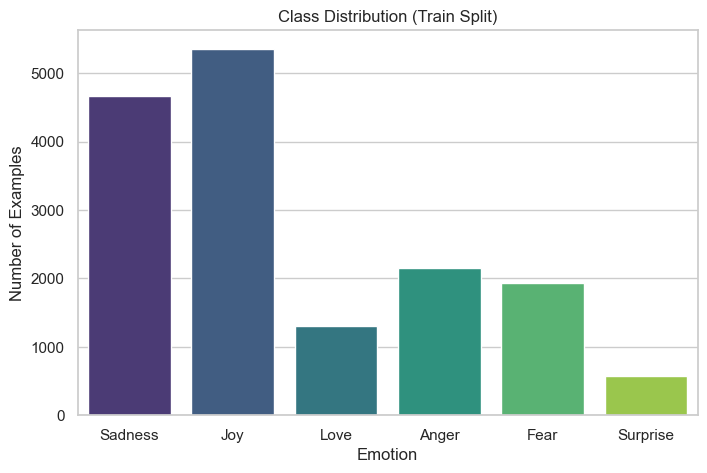

In [17]:
# Visualize class distribution (bar plot)
plt.figure(figsize=(8,5))
sns.barplot(
    x=[label_names[i] for i in label_counts.index],  # map numeric to name
    y=label_counts.values,
    palette="viridis"
)
plt.title("Class Distribution (Train Split)")
plt.ylabel("Number of Examples")
plt.xlabel("Emotion")
plt.show()


In [18]:
# Preview sample texts per label
print("\nSample text per emotion:")
for label in label_order:
    sample_text = train_df[train_df['label']==label]['clean_text'].iloc[0]
    print(f"{label} ({label_names[label]}): {sample_text}")


Sample text per emotion:
0 (Sadness): i didnt feel humiliated
1 (Joy): i have been with petronas for years i feel that petronas has performed well and made a huge profit
2 (Love): i am ever feeling nostalgic about the fireplace i will know that it is still on the property
3 (Anger): im grabbing a minute to post i feel greedy wrong
4 (Fear): i feel as confused about life as a teenager or as jaded as a year old man
5 (Surprise): ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny


## **7. Hugging Face Sentence-Transformer: Tokenization & Sentence Embeddings**

In [19]:
# Load Pretrained Sentence-Transformer Model

"""
We load the 'all-MiniLM-L6-v2' model from Hugging Face Sentence-Transformers.
This is a compact, efficient model trained for semantic similarity and
classification tasks. It will be used to encode text into dense embeddings.
"""

print("Loading SentenceTransformer model...")
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Preview the embedder information
print("\nEmbedder info:")
print(embedding_model)


Loading SentenceTransformer model...

Embedder info:
SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [20]:
# Encode text into embeddings
print("\nEncoding train/validation/test splits...")
X_train_embeddings = embedding_model.encode(
    train_df["clean_text"].tolist(), show_progress_bar=True
)
X_val_embeddings = embedding_model.encode(
    validation_df["clean_text"].tolist(), show_progress_bar=True
)
X_test_embeddings = embedding_model.encode(
    test_df["clean_text"].tolist(), show_progress_bar=True
)


Encoding train/validation/test splits...


Batches:   0%|          | 0/500 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [21]:
# Preview embeddings
print("\nEmbeddings shape:")
print(f"Train: {X_train_embeddings.shape}")
print(f"Validation: {X_val_embeddings.shape}")
print(f"Test: {X_test_embeddings.shape}")

print("\nExample vector (first 10 dims of first sample):")
print(X_train_embeddings[0][:10])



Embeddings shape:
Train: (16000, 384)
Validation: (2000, 384)
Test: (2000, 384)

Example vector (first 10 dims of first sample):
[-0.05505095 -0.00769685  0.06353018 -0.03966387  0.1169007  -0.12329585
  0.05808003  0.06770458  0.07172972 -0.1098157 ]


In [22]:
# Target labels
y_train = train_df["label"].values
y_val = validation_df["label"].values
y_test = test_df["label"].values


In [23]:
# Save embeddings
os.makedirs("artifacts/embeddings", exist_ok=True)
joblib.dump(X_train_embeddings, "artifacts/embeddings/train_embeddings.pkl")
joblib.dump(X_val_embeddings, "artifacts/embeddings/val_embeddings.pkl")
joblib.dump(X_test_embeddings, "artifacts/embeddings/test_embeddings.pkl")
print("\nEmbeddings saved in artifacts/embeddings/")


Embeddings saved in artifacts/embeddings/


## **8. Modeling**

In [ ]:
# Model: Logistic Regression

""" 
It is efficient, interpretable, and works well with dense embeddings 
like those produced by Sentence-Transformers.
"""

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1
)


In [25]:
# Train the model
print("Training Logistic Regression model...")
log_reg.fit(X_train_embeddings, y_train)

print("\nTraining complete.")


Training Logistic Regression model...

Training complete.


In [26]:
# Save the trained model
os.makedirs("models", exist_ok=True)
model_path = "models/logistic_regression_emotion_model.pkl"
joblib.dump(log_reg, model_path)

print(f"Model saved to: {model_path}")


Model saved to: models/logistic_regression_emotion_model.pkl


## **9. Evaluation**

Evaluating model...

Evaluation Summary:


,Split,Accuracy,F1 Macro,F1 Micro
0,Validation,0.6935,0.6089,0.6935
1,Test,0.6880,0.5925,0.6880



Classification Report (Test Set):
              precision    recall  f1-score   support

     Sadness       0.71      0.76      0.74       581
         Joy       0.71      0.82      0.76       695
        Love       0.54      0.38      0.44       159
       Anger       0.67      0.55      0.60       275
        Fear       0.64      0.61      0.62       224
    Surprise       0.61      0.29      0.39        66

    accuracy                           0.69      2000
   macro avg       0.65      0.57      0.59      2000
weighted avg       0.68      0.69      0.68      2000



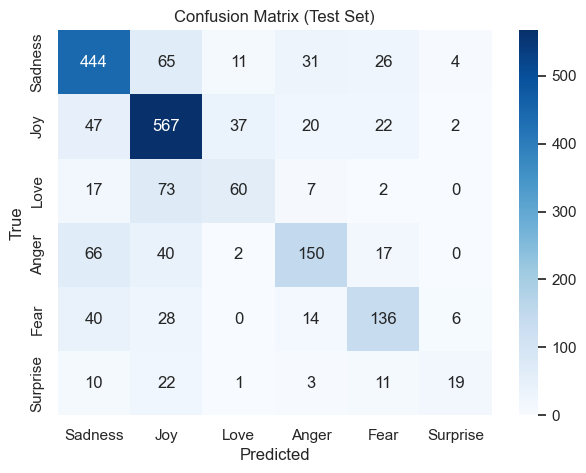

In [27]:
# Predictions on validation and test sets
print("Evaluating model...")
y_val_pred = log_reg.predict(X_val_embeddings)
y_test_pred = log_reg.predict(X_test_embeddings)

# Evaluation summary (Accuracy + F1)
def evaluate_split(name, y_true, y_pred):
    """Helper function to compute accuracy + F1 macro/micro"""
    return {
        "Split": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Macro": f1_score(y_true, y_pred, average="macro"),
        "F1 Micro": f1_score(y_true, y_pred, average="micro")
    }

results = []
results.append(evaluate_split("Validation", y_val, y_val_pred))
results.append(evaluate_split("Test", y_test, y_test_pred))
results_df = pd.DataFrame(results)

print("\nEvaluation Summary:")
display(results_df.round(4))

# Classification report (Test set)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=[label_names[i] for i in sorted(label_names.keys())]))

# Confusion matrix (Test set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[label_names[i] for i in sorted(label_names.keys())],
            yticklabels=[label_names[i] for i in sorted(label_names.keys())])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()


## **10. Inference**

In [31]:
# Load trained model & embeddings model
print("Loading trained model and embedding model...")
model_path = "models/logistic_regression_emotion_model.pkl"
log_reg = joblib.load(model_path)

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Inference function
def predict_emotion(text: str) -> str:
    """
    Predict emotion for a given input text.
    Steps:
    1. Preprocess text (same as training)
    2. Convert text into embedding
    3. Predict with trained classifier
    4. Map numeric label to emotion name
    """
    clean_text = preprocess_text(text)
    embedding = embedding_model.encode([clean_text])
    pred_label = log_reg.predict(embedding)[0]
    return label_names[pred_label]

# Test inference
sample_texts = [
    "I feel so lonely and heartbroken today.",
    "I am thrilled about my promotion at work!",
    "I cherish every moment we spend together.",
    "I am furious about what just happened!",
    "I’m terrified of walking home alone at night.",
    "Wow! I did not expect this amazing news!"
]

print("\nInference examples:")
for txt in sample_texts:
    print(f"Input: {txt}")
    print(f"Predicted Emotion: {predict_emotion(txt)}\n")


Loading trained model and embedding model...

Inference examples:
Input: I feel so lonely and heartbroken today.
Predicted Emotion: Sadness

Input: I am thrilled about my promotion at work!
Predicted Emotion: Joy

Input: I cherish every moment we spend together.
Predicted Emotion: Love

Input: I am furious about what just happened!
Predicted Emotion: Anger

Input: I’m terrified of walking home alone at night.
Predicted Emotion: Fear

Input: Wow! I did not expect this amazing news!
Predicted Emotion: Surprise

